# Salary Prediction

## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Regression](#regression)
- [Part III - Interpret Results](#interpret)


<a id='intro'></a>
### Introduction

Linear Regression is very commonly performed by data analysts and data scientists.  For this project, you will be working to understand the results of a Linear Regression model associated with salaries.


<a id='descriptive'></a>
#### Part I - Descriptive Statistics


In [2]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(0)

`1.a)` Now, read in the `salary_data.csv` data. Store it in `df`. Read in the dataset and take a look at the top few rows here. 

In [4]:
df = pd.read_csv('data/salary_data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


`b)` Use the below cell to find the number of rows in the dataset.

In [5]:
df.shape[0]

375

`c)` Do any of the rows have missing values? 

If there are missing values, determine a method for dealing with them.

In [6]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [7]:
df[df.isnull().any(axis=1)]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN


Every column has exactly 2 missing values, and it's the same 2 rows (index 172 and 260). Both rows are entirely blank, Age, Gender, Education Level, Job Title, Years of Experience, Salary all NaN. There's no partial record to salvage or impute — it's two blank lines in the data. So, the best approach is to drop these two rows from the dataset.

In [8]:
df_clean = df.dropna(how='all').reset_index(drop=True)
print(df_clean.shape)

(373, 6)


`d)` How many employees are in each `Education Level`? Build a bar chart to show the count of employees in each level.

In [9]:
edu_counts = df_clean['Education Level'].value_counts().reindex(["Bachelor's","Master's","PhD"])
print(edu_counts)

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64


Bachelor's = 224, Master's = 98, PhD = 51 and these sums up to 373 employees.  The bar chart is shown below.

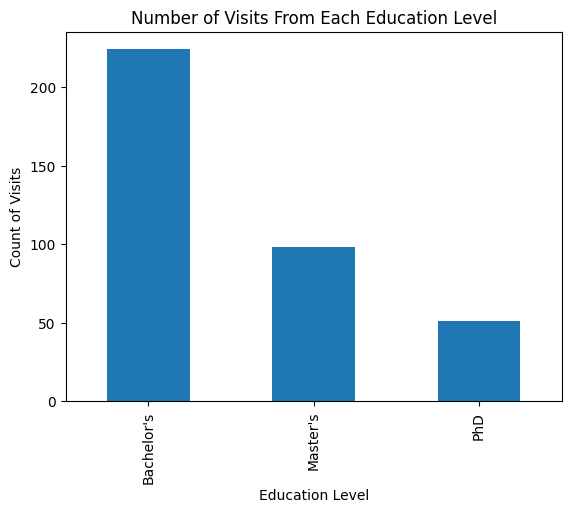

In [10]:
# bar chart of results - this part is done for you
df['Education Level'].value_counts().plot(kind='bar');
plt.title('Number of Visits From Each Education Level');
plt.ylabel('Count of Visits');
plt.show();

`e)` What are the possible values for `Salary`?  What does the distribution of `Salary` look like?

In [13]:
print(df_clean['Salary'].nunique())
print(df_clean['Salary'].describe())

36
count       373.000000
mean     100577.345845
std       48240.013482
min         350.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: Salary, dtype: float64


In [14]:
print(df_clean[['Age','Years of Experience','Salary']].corr())

                          Age  Years of Experience    Salary
Age                  1.000000             0.979128  0.922335
Years of Experience  0.979128             1.000000  0.930338
Salary               0.922335             0.930338  1.000000


<a id='regression'></a>
#### Part II - Regression

`1.` Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `Salary`.

`a)` Consider average salary by gender, is there evidence that salaries are higher for one gender over the other? **This question is completed for you**

In [15]:
df.groupby('Gender')['Salary'].mean()

Gender
Female     97011.173184
Male      103867.783505
Name: Salary, dtype: float64

Average Salary for 
- Male = $103,867.78
- Female = $97,011.17

`b)` Consider average salary by education level, is there evidence that salaries are higher for increased education?

In [19]:
df.groupby('Education Level')['Salary'].mean()

Education Level
Bachelor's     74756.026786
Master's      129795.918367
PhD           157843.137255
Name: Salary, dtype: float64

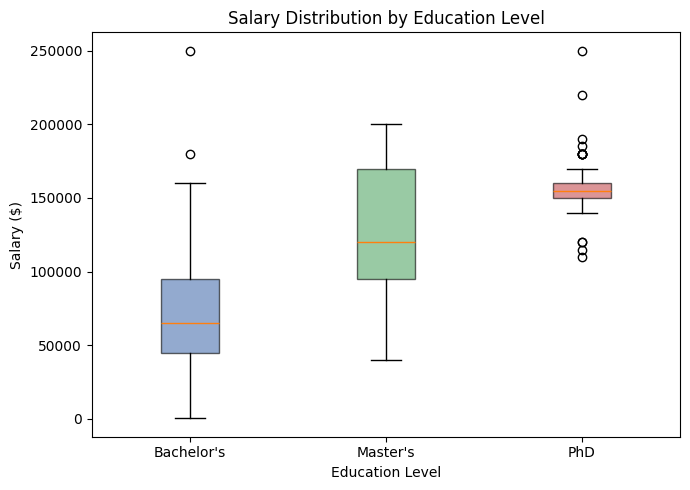

In [23]:
order = ["Bachelor's","Master's","PhD"]
data = [df_clean[df_clean['Education Level']==lvl]['Salary'].values for lvl in order]

fig, ax = plt.subplots(figsize=(7,5))
bp = ax.boxplot(data, tick_labels=order, patch_artist=True)  # 'labels' is deprecated in newer matplotlib
colors = ['#4C72B0','#55A868','#C44E52']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title('Salary Distribution by Education Level')
ax.set_xlabel('Education Level')
ax.set_ylabel('Salary ($)')
plt.tight_layout()
plt.savefig('salary_by_education.png', dpi=150)

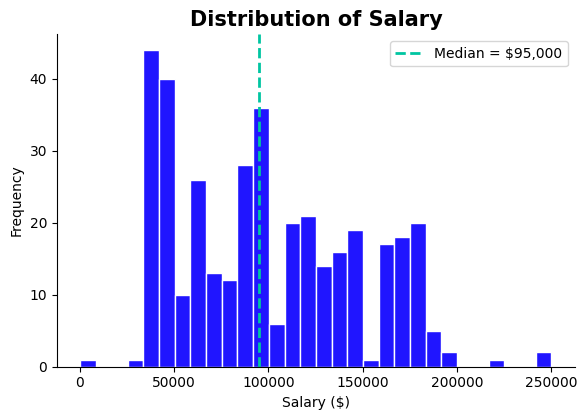

In [62]:
fig, ax = plt.subplots(figsize=(6,4.3))
ax.hist(df_clean['Salary'], bins=30, color='#2015FF', edgecolor='white')
ax.axvline(df_clean['Salary'].median(), color='#00C5A1', linestyle='--', linewidth=2,
           label=f"Median = ${df_clean['Salary'].median():,.0f}")
ax.set_title('Distribution of Salary', fontsize=15, fontweight='bold')
ax.set_xlabel('Salary ($)')
ax.set_ylabel('Frequency')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('salary_dist.png', dpi=200)

Yes, salaries are higher for increased education.  The average salary for
- Bachelor's ~= $75,000, 
- Master's ~= $130,000 and
- PhD ~= $158,000.

`c)` Consider average salary by years of experience, is there evidence that salaries are associated with increased years of experience?

In [20]:
df.groupby('Years of Experience')['Salary'].mean()

Years of Experience
0.0      33333.333333
0.5      35000.000000
1.0      37857.142857
1.5      36279.166667
2.0      41774.193548
3.0      51166.666667
4.0      58500.000000
5.0      64117.647059
6.0      83750.000000
7.0      84444.444444
8.0      88800.000000
9.0     101818.181818
10.0    100555.555556
11.0    100500.000000
12.0    105000.000000
13.0    120000.000000
14.0    125769.230769
15.0    134375.000000
16.0    157500.000000
17.0    143000.000000
18.0    149615.384615
19.0    166333.333333
20.0    168846.153846
21.0    173846.153846
22.0    162222.222222
23.0    177500.000000
24.0    250000.000000
25.0    200000.000000
Name: Salary, dtype: float64

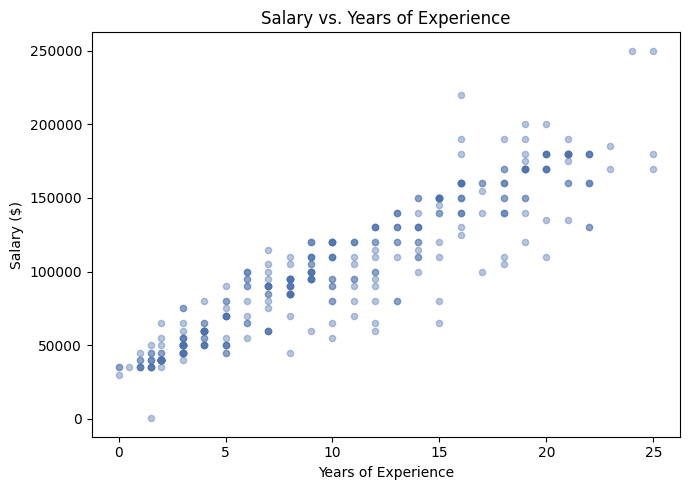

In [21]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df_clean['Years of Experience'], df_clean['Salary'], alpha=0.4, s=20, color='#4C72B0')
ax.set_title('Salary vs. Years of Experience')
ax.set_xlabel('Years of Experience')
ax.set_ylabel('Salary ($)')
plt.tight_layout()
plt.savefig('salary_vs_experience.png', dpi=150)

Yes, salaries are higher for more experience employees.  The average salary for
- 0-5 years of experience ranges from $30,000 to $65,000,
- 6-10 years of experience ranges from $84,000 to $100,000,
- 11-15 years of experience ranges from $100,500 to $134,000,
- 16-20 years of experience ranges from $157,000 to $168,000 and
- 21+ years of experience ranges from $175,000 to $200,000.

`d)`  To make use of Job Title column, let's create a bool flag based on word existence

List of words: 

* Director
* Junior
* Senior
* Manager
* Analyst
* Engineer

**This question is completed for you**

In [28]:
flag_words = ['director', 'junior', 'senior', 'manager', 'analyst', 'engineer']
df_clean['Job Title'] = df_clean['Job Title'].str.lower()

for word in flag_words:
    df_clean['is_' + word] = df_clean['Job Title'].str.contains(word)
    
df_clean = df_clean.drop('Job Title', axis=1)

`e)` Create a flag for gender where 1 is if a person is male and 0 if the person is not.

In [30]:
df_clean['male_flag'] = (df_clean['Gender'] == 'Male').astype(int)
print(df_clean[['Gender','male_flag']].drop_duplicates())

   Gender  male_flag
0    Male          1
1  Female          0


`f)` Use statsmodels to fit a linear model to predict salary using each of the features from `a-e`.  These include:
* Gender
* Job TItle
* Years of Experience
* Education

In [35]:
flag_cols = ['is_' + word for word in flag_words]


In [37]:
import statsmodels.formula.api as smf

df_clean = df_clean.rename(columns={
    'Years of Experience': 'YearsExperience',
    'Education Level': 'EducationLevel'
})

model = smf.ols(
    formula="Salary ~ male_flag + is_director + is_junior + is_senior + "
            "is_manager + is_analyst + is_engineer + YearsExperience + "
            "C(EducationLevel)",
    data=df_clean
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     391.7
Date:                Sun, 09 Aug 2026   Prob (F-statistic):          2.41e-187
Time:                        18:17:53   Log-Likelihood:                -4090.6
No. Observations:                 373   AIC:                             8203.
Df Residuals:                     362   BIC:                             8246.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

<a id='interpretation'></a>
### Part III - Interpret Results

`1.` Consider you are tasked with finding which features in your linear model are significantly related to salary.  Were there any features that were not significantly related to salary in your first model?  If not, remove those features and fit a new model.  Only keep the features that were significant from the original model.

Using the standard cutoff of p < 0.05 = significant, scanning the P>|t| column:

|Feature| p-value |Significant?|
|---------|-------------|------------|
|is_junior|	        0.068	    |No (just above 0.05)|
|is_analyst|	        0.933	    |No (nowhere close)|
|is_engineer|	        0.508	    |No|
|is_director|	        0.000	    |Yes|
|is_senior|	        0.000	    |Yes|
|is_manager|	        0.024	    |Yes|
|male_flag|	        0.000	    |Yes|
|YearsExperience|	    0.000	    |Yes|
|Edu: Master's|	    0.000	    |Yes|
|Edu: PhD|	        0.000	    |Yes|

Three features fail the significance test: is_junior, is_analyst, is_engineer

In [42]:
model_reduced = smf.ols(
    formula="Salary ~ male_flag + is_director + is_senior + is_manager + "
            "YearsExperience + C(EducationLevel)",
    data=df_clean
).fit()

print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     557.4
Date:                Sun, 09 Aug 2026   Prob (F-statistic):          1.46e-190
Time:                        21:13:33   Log-Likelihood:                -4092.6
No. Observations:                 373   AIC:                             8201.
Df Residuals:                     365   BIC:                             8233.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

n=373, p=8 (down from 11), R² = 0.9145, adjusted R² = 0.9126, condition number = 60.8

### What actually changed vs. the full model
- Every remaining variable is now solidly significant (all p < 0.02) after removiong the three non-significant variables — the dead weight cleanly.
- R² moved from 0.9154 → 0.9145 (a 0.0009 drop), and adjusted R² actually held essentially flat (0.9128 → 0.9126), confirming those three variables were genuinely not pulling weight in the original model. Good sign that the reduction was the right call, not a costly simplification.
- Coefficients shifted slightly but stayed directionally consistent: male_flag went from 7,485→7,630, YearsExperience 4,937→5,104, is_director/is_senior/is_manager all moved a bit but stayed in the same ballpark and kept their significance. Nothing flipped sign or fell apart — a good sign this reduced model is stable, not fragile.
- Condition number dropped slightly (63.1→60.8), marginal improvement, not the main story here (multicollinearity wasn't the issue driving the original three drops — genuine lack of signal was).

`a)` With each additional year of experience, what is the expected change in salary?  What is the 95% confidence interval of the change?

Coefficient: $5,104.44 per year. Holding gender, title level, and education constant, each additional year of experience is associated with an expected salary increase of about $5,104.

95% CI: [$4,755.93, $5,452.95]. Narrow interval relative to the estimate, and it's nowhere near zero, so this is a precisely estimated, clearly real effect — the strongest one in the model (t=28.8).

`b)` What is the expected difference in salary between someone with a senior title and someone with none of the other title indications?

The reference/baseline group is someone with none of is_director, is_senior, is_manager = True (i.e., none of those keywords appear in their job title).

Expected difference: from the Summary Table, is_senior[T.True]+$14,446.50. Someone with "senior" in their title earns about $14,446 more than an otherwise-identical person (same gender, experience, education) whose title contains none of the three keywords. 95% CI from the table: [$10,900, $18,000].

`c)` What is the expected difference in salary between someone with a PhD and an individual with no PhD nor master's degree?  What is the 95% confidence interval of the change?

In [ ]:
from scipy import stats as st

coef_phd = 23080.848715436456
se_phd   = 2760.739584364152

n, p = 373, 8          # model: No. Observations=373, Df Model=7 + intercept = 8 params
df_resid = n - p        # matches table's Df Residuals: 365

t_crit = st.t.ppf(0.975, df=df_resid)   # two-tailed 95% -> 0.975 quantile

ci_lower = coef_phd - t_crit * se_phd
ci_upper = coef_phd + t_crit * se_phd

print(t_crit)
print(ci_lower, ci_upper)

1.9664845963766746
17651.896848177006 28509.800582695905


Coefficient: $23,080.85.

95% CI: [$17,651.90, $28,509.80] (computed from your coefficient and std err using a t-critical value at df=365, matches the shape of your printed 1.77e4–2.85e4 range).

A PhD holder earns about $23,081 more than an otherwise-identical Bachelor's-degree employee, holding gender, title, and experience constant.

`d)` If a male employee has 5 years of experience as a senior engineer with a bachelor's degree, what is the expected salary of the employee?

In [48]:
keep_flags = ['is_director', 'is_senior', 'is_manager']
edu_dummies = pd.get_dummies(df_clean['EducationLevel'], prefix='Edu', drop_first=True)

X = pd.concat([
    df_clean[['male_flag'] + keep_flags + ['YearsExperience']].astype(float),
    edu_dummies.astype(float)
], axis=1)

X.insert(0, 'Intercept', 1.0)
names = X.columns.tolist()

y = df_clean['Salary'].values.astype(float)
beta, residuals, rank, singularvalues = np.linalg.lstsq(X.values, y, rcond=
                                                        None)

x_new = {c:  0.0 for c in names}
x_new['Intercept'] = 1.0
x_new['male_flag'] = 1.0
x_new['is_senior'] = 1.0
x_new['YearsExperience'] = 5.0

x_vec = np.array([x_new[c] for c in X.columns])
pred = x_vec @ beta
print(pred)

76359.10538662052


Expected salary = $76,359.11

`e)` Imagine that the employee in question `d)` actually has a salary of $110,000, what would the residual be for this employee?

In [52]:
# Residual = Actual Salary - Predicted Salary 
(110000 - 76359.11)


33640.89

Residual = Actual Salary - Predicted Salary = $110,000 - $76,359.11 = $33,640.89

`f)` How well do you think your model fits?  What metrics or plots would you consider to understand if this model does a good job of predicting salary?

In [53]:
fitted = X.values @ beta
resid = y - fitted

r2 = 1 - np.sum(resid**2)/np.sum((y-y.mean())**2)
rmse = np.sqrt(np.mean(resid**2))
mae = np.mean(np.abs(resid))

print("R2:", r2, "RMSE:", rmse, "MAE:", mae)

R2: 0.9144608856149655 RMSE: 14089.865561844526 MAE: 9601.64087008701


**Model fits Decently**

#### Metrics to Consider are R², RMSE, and MAE
- R² = 0.9145 — explains ~91% of salary variance.
- RMSE = $14,089.87 — typical prediction error, penalizing big misses more heavily.
- MAE = $9,601.64 — typical prediction error in absolute terms, less sensitive to outliers.
- RMSE relative to mean salary ($100,577): ~14%. For a salary prediction model, being off by ~14% on a typical case is meaningful — this isn't a model I'd trust for individual compensation decisions without caveats.

RMSE being 47% larger than MAE ($14,090 vs $9,602) is itself diagnostic: if errors were small and evenly spread, these two would be close together. The gap means a handful of big misses are dragging RMSE up disproportionately.

In [55]:
resid_df = pd.DataFrame({'actual':y, 'fitted':fitted, 'resid':resid})
print(resid_df.sort_values('resid', ascending=False).head(5))   # underpredicted
print()
print(resid_df.sort_values('resid').head(5))                    # overpredicted

       actual         fitted         resid
30   250000.0  164001.404975  85998.595025
105  220000.0  141142.304828  78857.695172
83   250000.0  181977.814928  68022.185072
53   200000.0  147412.090761  52587.909239
21   190000.0  147412.090761  42587.909239

       actual         fitted         resid
116   65000.0  109612.024679 -44612.024679
258     350.0   44047.094055 -43697.094055
104   80000.0  123602.281704 -43602.281704
88   135000.0  176352.103422 -41352.103422
52    60000.0   90014.048918 -30014.048918


- Worst underprediction: actual $250,000, predicted $164,001 (off by $86,000).
- Worst overprediction: actual $350 (your flagged outlier), predicted $44,047 (off by $43,697) — the model has no way to predict near-zero salaries since nothing in the feature set signals "this is likely a data-entry error," it just predicts based on experience/title/education like any other row.

### Plots to Consider are Scatterplots of predicted vs actual, and a Q-Q plot of residuals to check for normality.

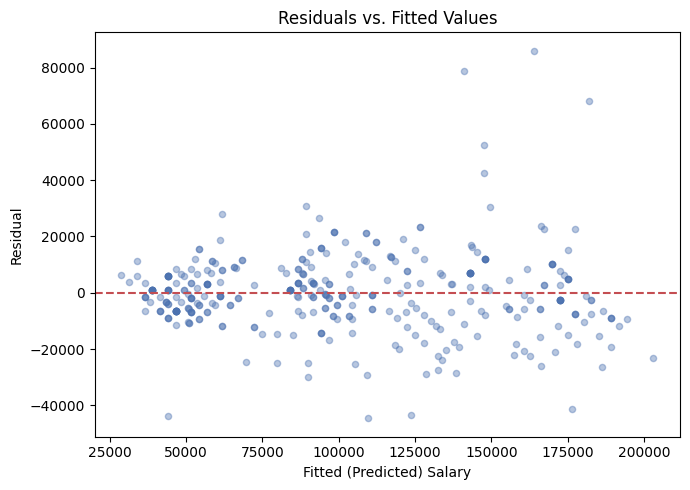

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(fitted, resid, alpha=0.4, s=20, color='#4C72B0')
ax.axhline(0, color='#C44E52', linestyle='--')
ax.set_xlabel('Fitted (Predicted) Salary')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs. Fitted Values')
plt.tight_layout()
plt.savefig('residuals_vs_fitted.png', dpi=150)

Qq Plot

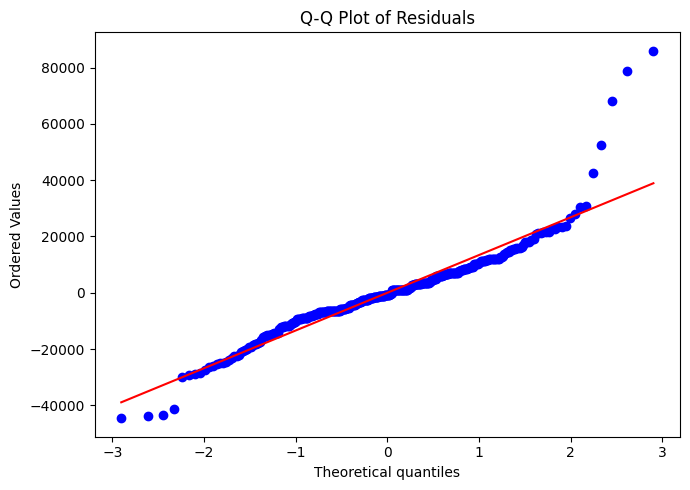

In [58]:
fig, ax = plt.subplots(figsize=(7,5))
st.probplot(resid, dist="norm", plot=ax)
ax.set_title('Q-Q Plot of Residuals')
plt.tight_layout()
plt.savefig('qq_plot.png', dpi=150)

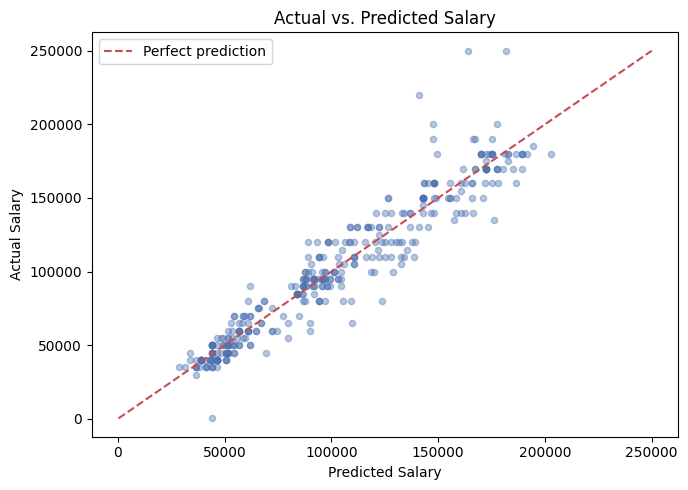

In [59]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(fitted, y, alpha=0.4, s=20, color='#4C72B0')
lims = [min(fitted.min(), y.min()), max(fitted.max(), y.max())]
ax.plot(lims, lims, color='#C44E52', linestyle='--', label='Perfect prediction')
ax.set_xlabel('Predicted Salary')
ax.set_ylabel('Actual Salary')
ax.set_title('Actual vs. Predicted Salary')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)